In [116]:
import os

if "GROQ_API_KEY" not in os.environ:
    raise EnvironmentError("GROQ_API_KEY environment variable is not set.") 

In [117]:
from langchain_groq import ChatGroq
llm = ChatGroq(model="llama-3.1-8b-instant", temperature=0.5)

Extract the Tool DuckDuckGo search

In [118]:
from langchain_core.tools import tool

@tool
def Duck_Search(query: str) -> str:
    '''This function performs a search using the DuckDuckGo search engine and returns the results.'''
    duck_search = DuckDuckGoSearchRun()
    return duck_search.invoke(query)


Custom Tool

In [119]:
@tool
def custom_tool(query: str) -> str:
    '''This function provide the personal information of the user.'''
    info = {
        "Alice": "Alice is a software engineer with 5 years of experience in machine learning.",
        "Bob": "Bob is a data scientist who specializes in natural language processing.",
        "Charlie": "Charlie is a product manager with a background in AI and cloud computing."
    }
    return info.get(query, "No information available for this user.")

WikiPedia Tool


In [120]:
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

@tool
def wikipedia_search(query: str) -> str:
    '''This function performs a search using the Wikipedia API and returns the results.'''

    try:
        wiki_query = WikipediaQueryRun(api_wrapper= WikipediaAPIWrapper())
        return wiki_query.invoke(query)

    except Exception as e:
        return f"Wikipedia Error: {str(e)} "


Tool binder for binding llm and tool

In [121]:
tool_list = [Duck_Search,custom_tool,wikipedia_search]
llm_bind_tools = llm.bind_tools(tool_list)

Invoke the message in llm bind tools

In [122]:
response = llm_bind_tools.invoke("What is the latest news on AI")
print(response)

content='' additional_kwargs={'tool_calls': [{'id': '3fkpey7ks', 'function': {'arguments': '{"query":"latest news on AI"}', 'name': 'wikipedia_search'}, 'type': 'function'}]} response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 367, 'total_tokens': 385, 'completion_time': 0.032222812, 'completion_tokens_details': None, 'prompt_time': 0.023410702, 'prompt_tokens_details': None, 'queue_time': 0.052781048, 'total_time': 0.055633514}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'} id='lc_run--019e119b-7dbd-72b0-ba5c-be026f037415-0' tool_calls=[{'name': 'wikipedia_search', 'args': {'query': 'latest news on AI'}, 'id': '3fkpey7ks', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_tokens': 367, 'output_tokens': 18, 'total_tokens': 385}


In [123]:
response.tool_calls

[{'name': 'wikipedia_search',
  'args': {'query': 'latest news on AI'},
  'id': '3fkpey7ks',
  'type': 'tool_call'}]

Create a Graph Schema

In [124]:
from typing import List, TypedDict

class Graph_Schema(TypedDict):
    message: List
    

Create a Node

In [125]:
#create a llm node
from langchain_core.prompts  import ChatPromptTemplate

def Llm_Node(state: Graph_Schema) -> Graph_Schema:
    message = state["message"]

    prompt = ChatPromptTemplate.from_messages(
        [
            ("system", "You are a helpful assistant that provides information about the latest news on AI."),
            ("human", "{input}")
        ]
    )
     
    # Lets define the chain
    chain = prompt | llm_bind_tools

    #Now we can invoke the chain with the input message
    response = chain.invoke({"input": message})

    #We can now update the state with the response from the llm
    state["message"] = message + [response]
    return state


Create the tool Node -> we can create the tool node using the prebuilt func from langgraph.prebuilt import ToolNode bur for now we create manually using python, it promotes the customization of code.

In [126]:
from langchain_core.messages import ToolMessage, HumanMessage, AIMessage

def tool_node(state: Graph_Schema) -> Graph_Schema:
    message = state["message"]

    # lets store tool_list into a dictionary for easy access where tool_name and func are stored
    tool_by_name = {tool.name: tool for tool in tool_list}

    tool_results = []

    for tool in message[-1].tool_calls: # k vaiarxa vaney last message -> Ai message an ai message ma content,tool_calls xa as a key so we call tool_calls

        tool_name = tool_by_name[tool["name"]]  # tool ko function aauxa

        observation = tool_name.invoke(tool["args"])  # tool ko function ma args pathaune and result observation ma aauxa

        tool_results.append(ToolMessage(content = observation, tool_call_id = tool["id"])) # tool ko result lai tool message ma store garne

    
    #Update the state with tool message 
    state["message"] = message + tool_results
    return state


CREATE A STATEGRAPH

In [127]:
def if_tool_call(state) -> str:
    last_message = state["message"][-1]

    if last_message.tool_calls:
        return "tool_node"

    else:
        return "end"


In [128]:
from langgraph.graph import StateGraph,START,END

graph = StateGraph(Graph_Schema)

#add nodes into graph since node is already created
graph.add_node("llm_node",Llm_Node)
graph.add_node("tool_node",tool_node)

#add edges to the  graph
graph.add_edge(START,"llm_node")

# meaning: if router returns "tool_node" → go to tool_node  if router returns "end" → stop graph
graph.add_conditional_edges("llm_node",if_tool_call,{"tool_node":"tool_node","end":END}) 
graph.add_edge("tool_node","llm_node")
graph.add_edge("llm_node",END)


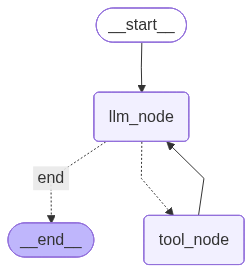

In [129]:
#compile the graph
from IPython.display import display,Image
react_graph = graph.compile()
Image(react_graph.get_graph().draw_mermaid_png())

Graph Invocation

In [130]:
react_graph.invoke({"message": [HumanMessage(content="Latest News on AI")]})

{'message': [HumanMessage(content='Latest News on AI', additional_kwargs={}, response_metadata={}),
  AIMessage(content='Duck_Search>{"query": "latest news on AI"} \ncustom_tool>{"query": "latest news on AI"} \nbrave_search>{"query": "latest news on AI"}', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 38, 'prompt_tokens': 393, 'total_tokens': 431, 'completion_time': 0.051894701, 'completion_tokens_details': None, 'prompt_time': 0.023743655, 'prompt_tokens_details': None, 'queue_time': 0.052914805, 'total_time': 0.075638356}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e119b-838e-77e0-9b8b-6e5a133cc2cc-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 393, 'output_tokens': 38, 'total_tokens': 431})]}